In [1]:
import xarray as xr
from dask.distributed import LocalCluster, Client 


cluster = LocalCluster(n_workers=4, memory_limit='8GiB')
client = Client(cluster)
client

/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46043 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46043/status,
Dashboard: http://127.0.0.1:46043/status,Workers: 4
Total threads: 64,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38115,Workers: 4
Dashboard: http://127.0.0.1:46043/status,Total threads: 64
Started: Just now,Total memory: 32.00 GiB
Comm: tcp://127.0.0.1:36851,Total threads: 16
Dashboard: http://127.0.0.1:45335/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:41967,


In [ ]:
ds = xr.open_dataset('/Data/gfi/users/rogui7909/data/precip/SeNorge2/seNorge2_PREC1d_dataset_1957_2015.nc', chunks='auto')

In [ ]:
ds_WN = ds.sel(X=slice(None,0.06e6), Y=slice(7e6,6.6e6)).mean(['X','Y'], keep_attrs=True)

In [ ]:
ds_WN[['precipitation_amount']].rename(precipitation_amount='tp').to_netcdf('/Data/gfi/users/rogui7909/data/precip/SeNorge2/WestNorway_timesries_seNorge2_PREC1d_dataset_1957_2015.nc')

In [3]:
with xr.open_dataset('/Data/gfi/users/rogui7909/data/precip/SeNorge2/WestNorway_timesries_seNorge2_PREC1d_dataset_1957_2015.nc') as ds:
    ds_2 = ds.rename(precipitation_amount='tp')

In [5]:
ds_2.to_netcdf('/Data/gfi/users/rogui7909/data/precip/SeNorge2/WestNorway_timesries_seNorge2_PREC1d_dataset_1957_2015.nc')

KeyError: 'precipitation_amount'

In [18]:
ds_2.variables[0]

KeyError: 0

In [12]:
ds_ = xr.DataArray(ds_2.tp.values, coords=ds_2.coords, dims=ds_2.dims, attrs=ds_2.attrs, name='tp')

KeyError: 'precipitation_amount'

In [11]:
ds_2.tp.rename('precipitation_amount').to_netcdf('/Data/gfi/users/rogui7909/data/precip/SeNorge2/WestNorway_timesries_seNorge2_PREC1d_dataset_1957_2015.nc_')

KeyError: 'precipitation_amount'

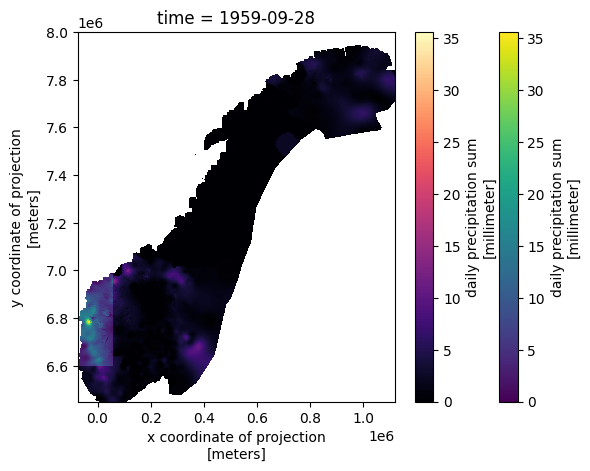

In [19]:
ds_WN.precipitation_amount.isel(time=1000).plot()
ds.precipitation_amount.isel(time=1000).plot(zorder=0, cmap='magma')
